In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as patches
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, BatchNormalization, Dropout, Normalization, Input
from tensorflow.keras.optimizers import Adam
import os


c:\Users\Jase.LAPTOP-UM736EL9\AppData\Local\Programs\Python\Python310\lib\site-packages\google\api_core\_python_version_support.py:273: FutureWarning: You are using a Python version (3.10.0) which Google will stop supporting in new releases of google.api_core once it reaches its end of life (2026-10-04). Please upgrade to the latest Python version, or at least Python 3.11, to continue receiving updates for google.api_core past that date.
  warnings.warn(message, FutureWarning)


In [2]:
np.random.seed(42)
tf.random.set_seed(42)
n_samples = 50000

In [3]:
damage_count = np.random.randint(1, 200, size=n_samples)
affected_kk = np.maximum(1, np.round(damage_count * np.random.uniform(0.9, 1.2, size=n_samples))).astype(int)
total_population = affected_kk * np.random.randint(3, 6, size=n_samples)
disaster_type_enc = np.random.randint(0, 6, size=n_samples)
severity_level = np.random.randint(1, 6, size=n_samples)
emergency_duration = np.random.choice([3, 7, 10, 14], size=n_samples)
vulnerability_idx = np.random.uniform(0.1, 1.0, size=n_samples)

duration_factor = emergency_duration / 10.0

beras_kg = np.round(affected_kk * 5.0 * duration_factor * np.random.uniform(0.96, 1.04, size=n_samples), 1)
minyak_liter = np.round(affected_kk * 1.0 * duration_factor * np.random.uniform(0.96, 1.04, size=n_samples), 1)
gula_kg = np.round(affected_kk * 1.0 * duration_factor * np.random.uniform(0.96, 1.04, size=n_samples), 1)
indomie_pcs = np.round(affected_kk * 5.0 * duration_factor * np.random.uniform(0.96, 1.04, size=n_samples)).astype(int)
roma_sari_gandum_pack = np.round(affected_kk * 1.0 * duration_factor * np.random.uniform(0.96, 1.04, size=n_samples)).astype(int)
roma_malkist_abon_pack = np.round(affected_kk * 1.0 * duration_factor * np.random.uniform(0.96, 1.04, size=n_samples)).astype(int)
roma_kelapa_pack = np.round(affected_kk * 1.0 * duration_factor * np.random.uniform(0.96, 1.04, size=n_samples)).astype(int)
roma_marie_susu_pack = np.round(affected_kk * 1.0 * duration_factor * np.random.uniform(0.96, 1.04, size=n_samples)).astype(int)
sarden_pcs = np.round(affected_kk * 1.0 * duration_factor * np.random.uniform(0.96, 1.04, size=n_samples)).astype(int)
kornet_pcs = np.round(affected_kk * 1.0 * duration_factor * np.random.uniform(0.96, 1.04, size=n_samples)).astype(int)
susu_full_cream_pcs = np.round(affected_kk * 1.0 * duration_factor * np.random.uniform(0.96, 1.04, size=n_samples)).astype(int)
susu_dancow_box = np.round(affected_kk * 1.0 * duration_factor * np.random.uniform(0.96, 1.04, size=n_samples)).astype(int)

matras_pcs = affected_kk.copy()
kasur_lipat_pcs = affected_kk.copy()
kompor_set = affected_kk.copy()
karpet_plastik_pcs = affected_kk.copy()
kipas_angin_pcs = np.where(disaster_type_enc == 0, affected_kk, np.round(affected_kk * 0.5).astype(int))

In [4]:
x = pd.DataFrame({
    "damage_count": damage_count,
    "affected_kk": affected_kk,
    "total_population": total_population,
    "disaster_type_enc": disaster_type_enc,
    "severity_level": severity_level,
    "emergency_duration": emergency_duration,
    "vulnerability_idx": vulnerability_idx
})

y = pd.DataFrame({
    "beras_kg": beras_kg,
    "minyak_liter": minyak_liter,
    "gula_kg": gula_kg,
    "indomie_pcs": indomie_pcs,
    "roma_sari_gandum_pack": roma_sari_gandum_pack,
    "roma_malkist_abon_pack": roma_malkist_abon_pack,
    "roma_kelapa_pack": roma_kelapa_pack,
    "roma_marie_susu_pack": roma_marie_susu_pack,
    "sarden_pcs": sarden_pcs,
    "kornet_pcs": kornet_pcs,
    "susu_full_cream_pcs": susu_full_cream_pcs,
    "susu_dancow_box": susu_dancow_box,
    "matras_pcs": matras_pcs,
    "kasur_lipat_pcs": kasur_lipat_pcs,
    "kompor_set": kompor_set,
    "karpet_plastik_pcs": karpet_plastik_pcs,
    "kipas_angin_pcs": kipas_angin_pcs
})

In [5]:
print("Dimensi Dataset:", x.shape, y.shape)

Dimensi Dataset: (50000, 7) (50000, 17)


In [6]:
x.head()

,damage_count,affected_kk,total_population,disaster_type_enc,severity_level,emergency_duration,vulnerability_idx
0,103,109,327,2,2,3,0.339850
1,180,164,820,4,5,3,0.556171
2,93,85,255,3,2,3,0.960676
3,15,14,70,4,5,3,0.536423
4,107,101,404,2,1,14,0.130838


In [7]:
y.head()

,beras_kg,minyak_liter,gula_kg,indomie_pcs,roma_sari_gandum_pack,roma_malkist_abon_pack,roma_kelapa_pack,roma_marie_susu_pack,sarden_pcs,kornet_pcs,susu_full_cream_pcs,susu_dancow_box,matras_pcs,kasur_lipat_pcs,kompor_set,karpet_plastik_pcs,kipas_angin_pcs
0,157.1,33.7,32.5,158,33,33,33,34,34,31,33,33,109,109,109,109,54
1,249.4,50.5,50.6,254,49,50,48,51,47,51,50,49,164,164,164,164,82
2,125.6,25.4,25.9,130,26,26,25,25,25,25,25,26,85,85,85,85,42
3,20.7,4.3,4.2,22,4,4,4,4,4,4,4,4,14,14,14,14,7
4,706.6,136.7,140.5,699,140,136,147,146,146,147,142,138,101,101,101,101,50


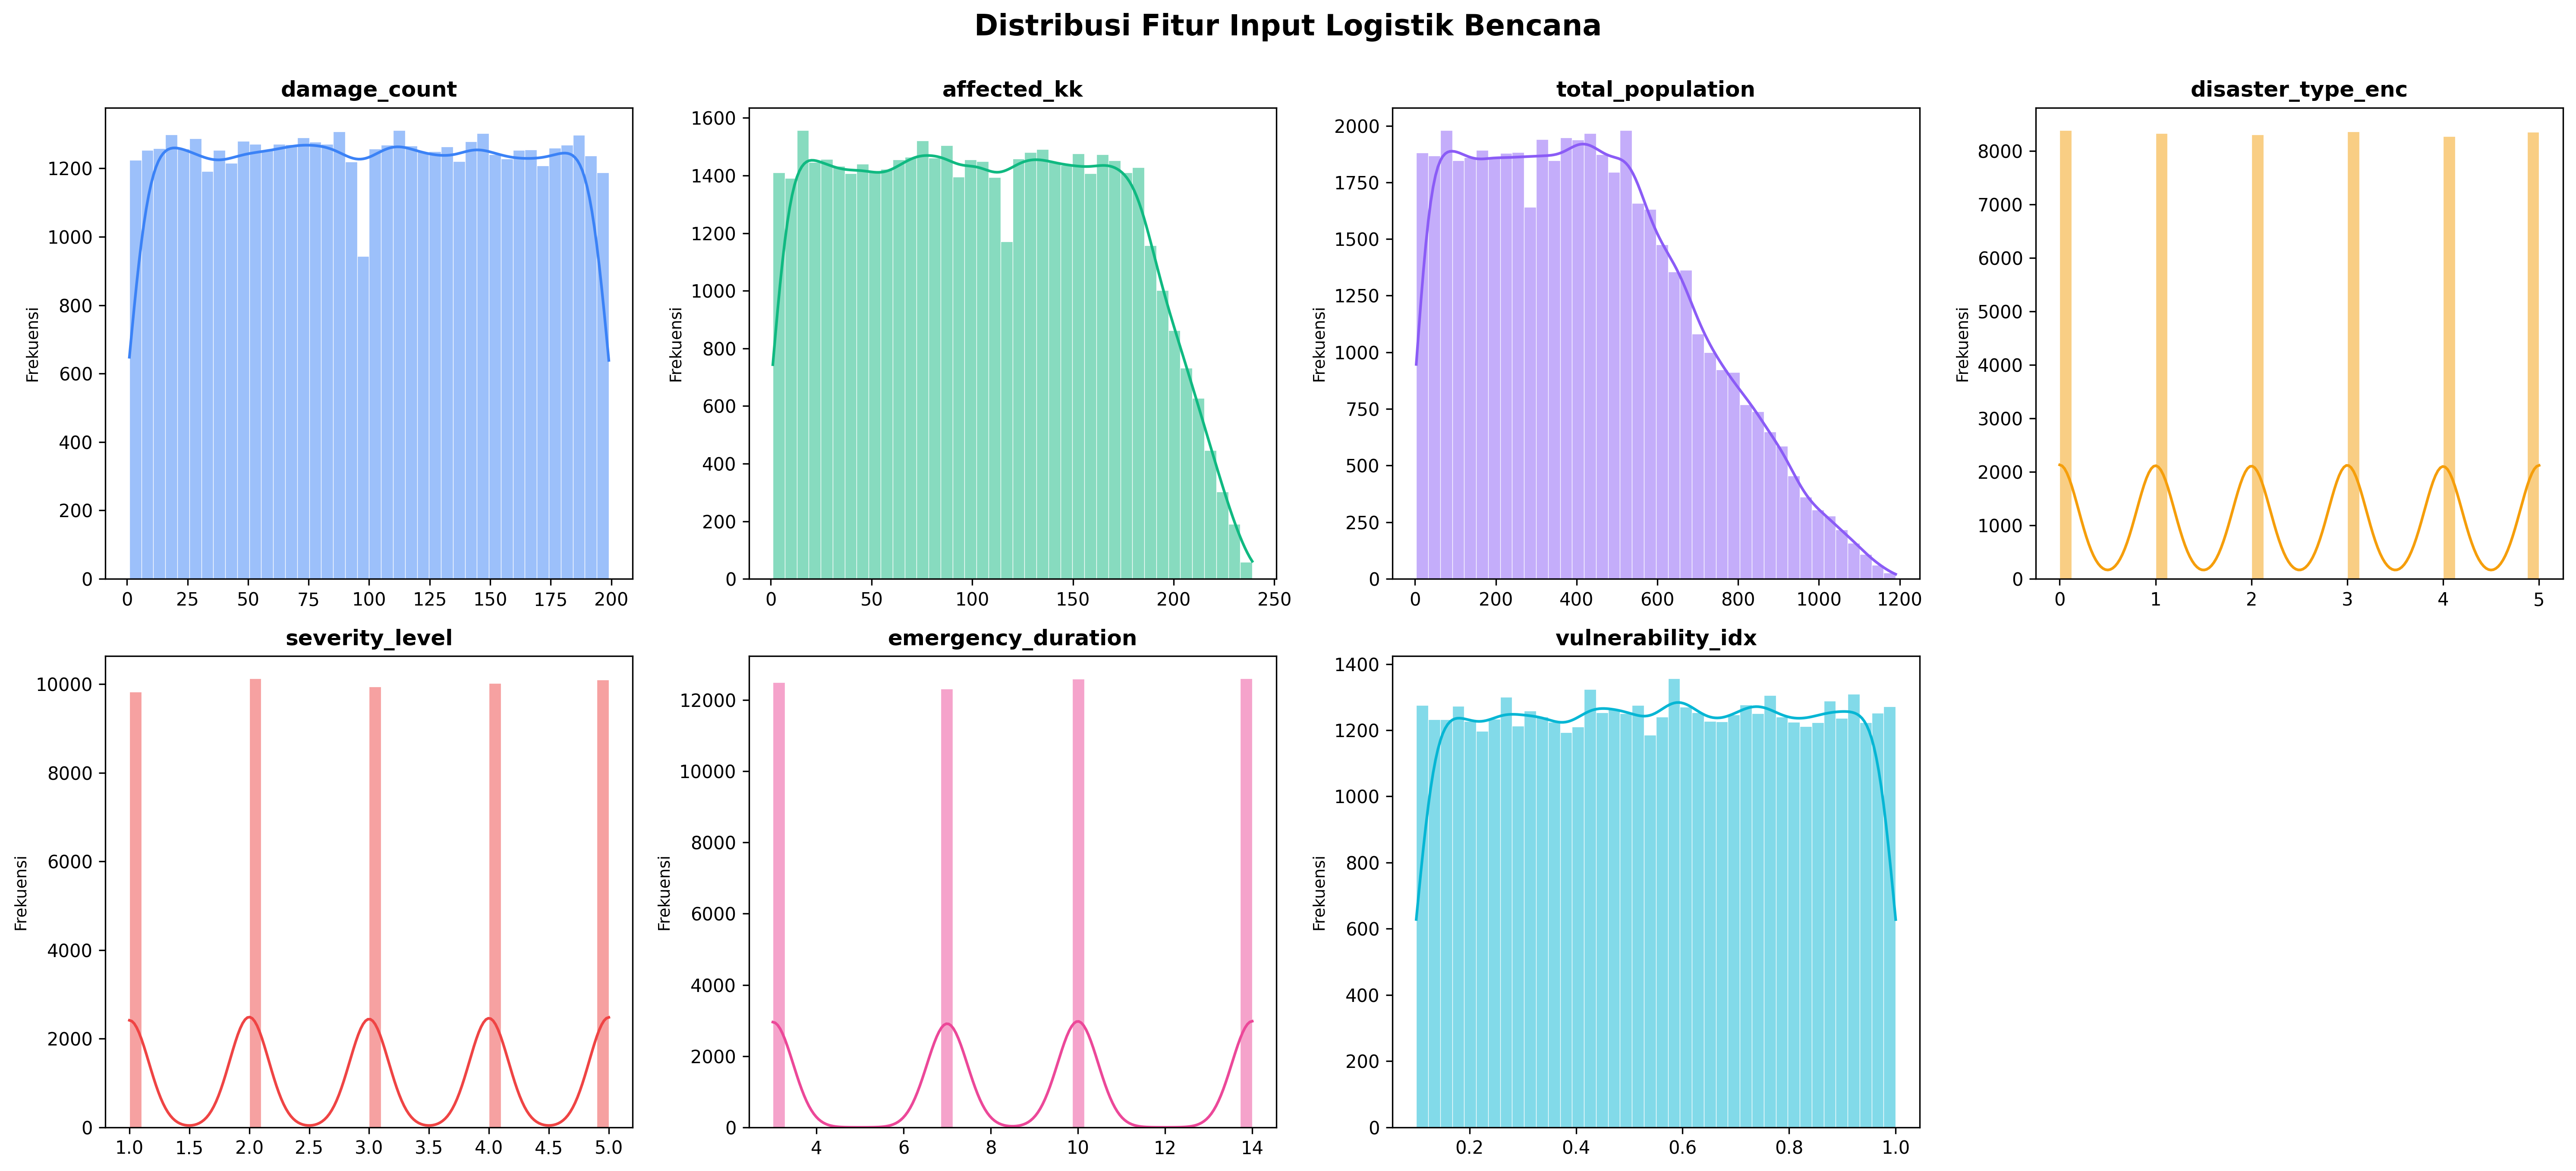

In [8]:
fig, axes = plt.subplots(2, 4, figsize=(20, 9), dpi=300)
axes = axes.flatten()
feature_colors = ['#3B82F6', '#10B981', '#8B5CF6', '#F59E0B', '#EF4444', '#EC4899', '#06B6D4']
for i, col in enumerate(x.columns):
    sns.histplot(x[col], kde=True, ax=axes[i], color=feature_colors[i], bins=40, edgecolor='white', linewidth=0.3)
    axes[i].set_title(col, fontsize=12, fontweight='bold')
    axes[i].set_xlabel('')
    axes[i].set_ylabel('Frekuensi', fontsize=9)
axes[7].axis('off')
plt.suptitle('Distribusi Fitur Input Logistik Bencana', fontsize=16, fontweight='bold', y=1.00)
plt.tight_layout()
plt.savefig('Feature_Distribution_Analysis.png', dpi=300, bbox_inches='tight')
plt.show()

In [9]:
target_labels = [
    "Beras (kg)", "Minyak Goreng (L)", "Gula Pasir (kg)", "Mie Instan (pcs)",
    "Sari Gandum (pack)", "Malkist Abon (pack)", "Roma Kelapa (pack)", "Marie Susu (pack)",
    "Sarden (kaleng)", "Kornet (kaleng)", "Susu Full Cream (pcs)", "Susu Dancow (box)",
    "Matras (pcs)", "Kasur Lipat (pcs)", "Kompor (set)", "Karpet Plastik (pcs)", "Kipas Angin (pcs)"
]

fig, axes = plt.subplots(5, 4, figsize=(24, 28), dpi=300)
axes = axes.flatten()

palette = [
    '#3B82F6', '#10B981', '#F59E0B', '#EF4444', '#8B5CF6',
    '#EC4899', '#06B6D4', '#F97316', '#14B8A6', '#A855F7',
    '#E11D48', '#0EA5E9', '#84CC16', '#D946EF', '#FB923C',
    '#22D3EE', '#F43F5E'
]

for i, col in enumerate(y.columns):
    ax = axes[i]
    data = y[col]
    sns.histplot(data, kde=True, ax=ax, color=palette[i], bins=40, edgecolor='white', linewidth=0.3, alpha=0.85)

    mean_val = data.mean()
    std_val = data.std()
    min_val = data.min()
    max_val = data.max()

    ax.axvline(mean_val, color='#1e293b', linestyle='--', linewidth=1.5, label=f'Mean: {mean_val:.1f}')
    ax.axvline(mean_val - std_val, color='#64748b', linestyle=':', linewidth=1, alpha=0.7)
    ax.axvline(mean_val + std_val, color='#64748b', linestyle=':', linewidth=1, alpha=0.7)

    stats_text = f'Mean: {mean_val:.1f}\nStd: {std_val:.1f}\nMin: {min_val:.1f}\nMax: {max_val:.1f}'
    ax.text(0.97, 0.95, stats_text, transform=ax.transAxes, fontsize=8, verticalalignment='top',
            horizontalalignment='right', bbox=dict(boxstyle='round,pad=0.4', facecolor='white', edgecolor='#cbd5e1', alpha=0.9))

    ax.set_title(target_labels[i], fontsize=11, fontweight='bold', pad=8)
    ax.set_xlabel('')
    ax.set_ylabel('')
    ax.tick_params(labelsize=8)

for j in range(len(y.columns), len(axes)):
    axes[j].set_visible(False)

fig.suptitle('Distribusi Data Target 17 Item Logistik Kemanusiaan dan Karakteristik Varians',
             fontsize=16, fontweight='bold', y=0.995)
plt.tight_layout(rect=[0, 0, 1, 0.98])
plt.savefig('Distribution.png', bbox_inches='tight')
plt.show()

In [10]:
X_train, X_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=42)

In [11]:
mean_vals = X_train.mean().values
std_vals = X_train.std().values

In [12]:
norm_layer = Normalization(mean=mean_vals, variance=std_vals**2)

In [13]:
from shapely.geometry import shape

In [14]:
model = Sequential()

model.add(Input(shape=(7,)))

model.add(norm_layer)

model.add(Dense(256, activation="relu"))
model.add(BatchNormalization())
model.add(Dropout(0.3))

model.add(Dense(128, activation="relu"))
model.add(BatchNormalization())
model.add(Dropout(0.3))

model.add(Dense(64, activation="relu"))
model.add(BatchNormalization())
model.add(Dropout(0.3))

model.add(Dense(32, activation="relu"))

model.add(Dense(y_train.shape[1], activation="linear"))

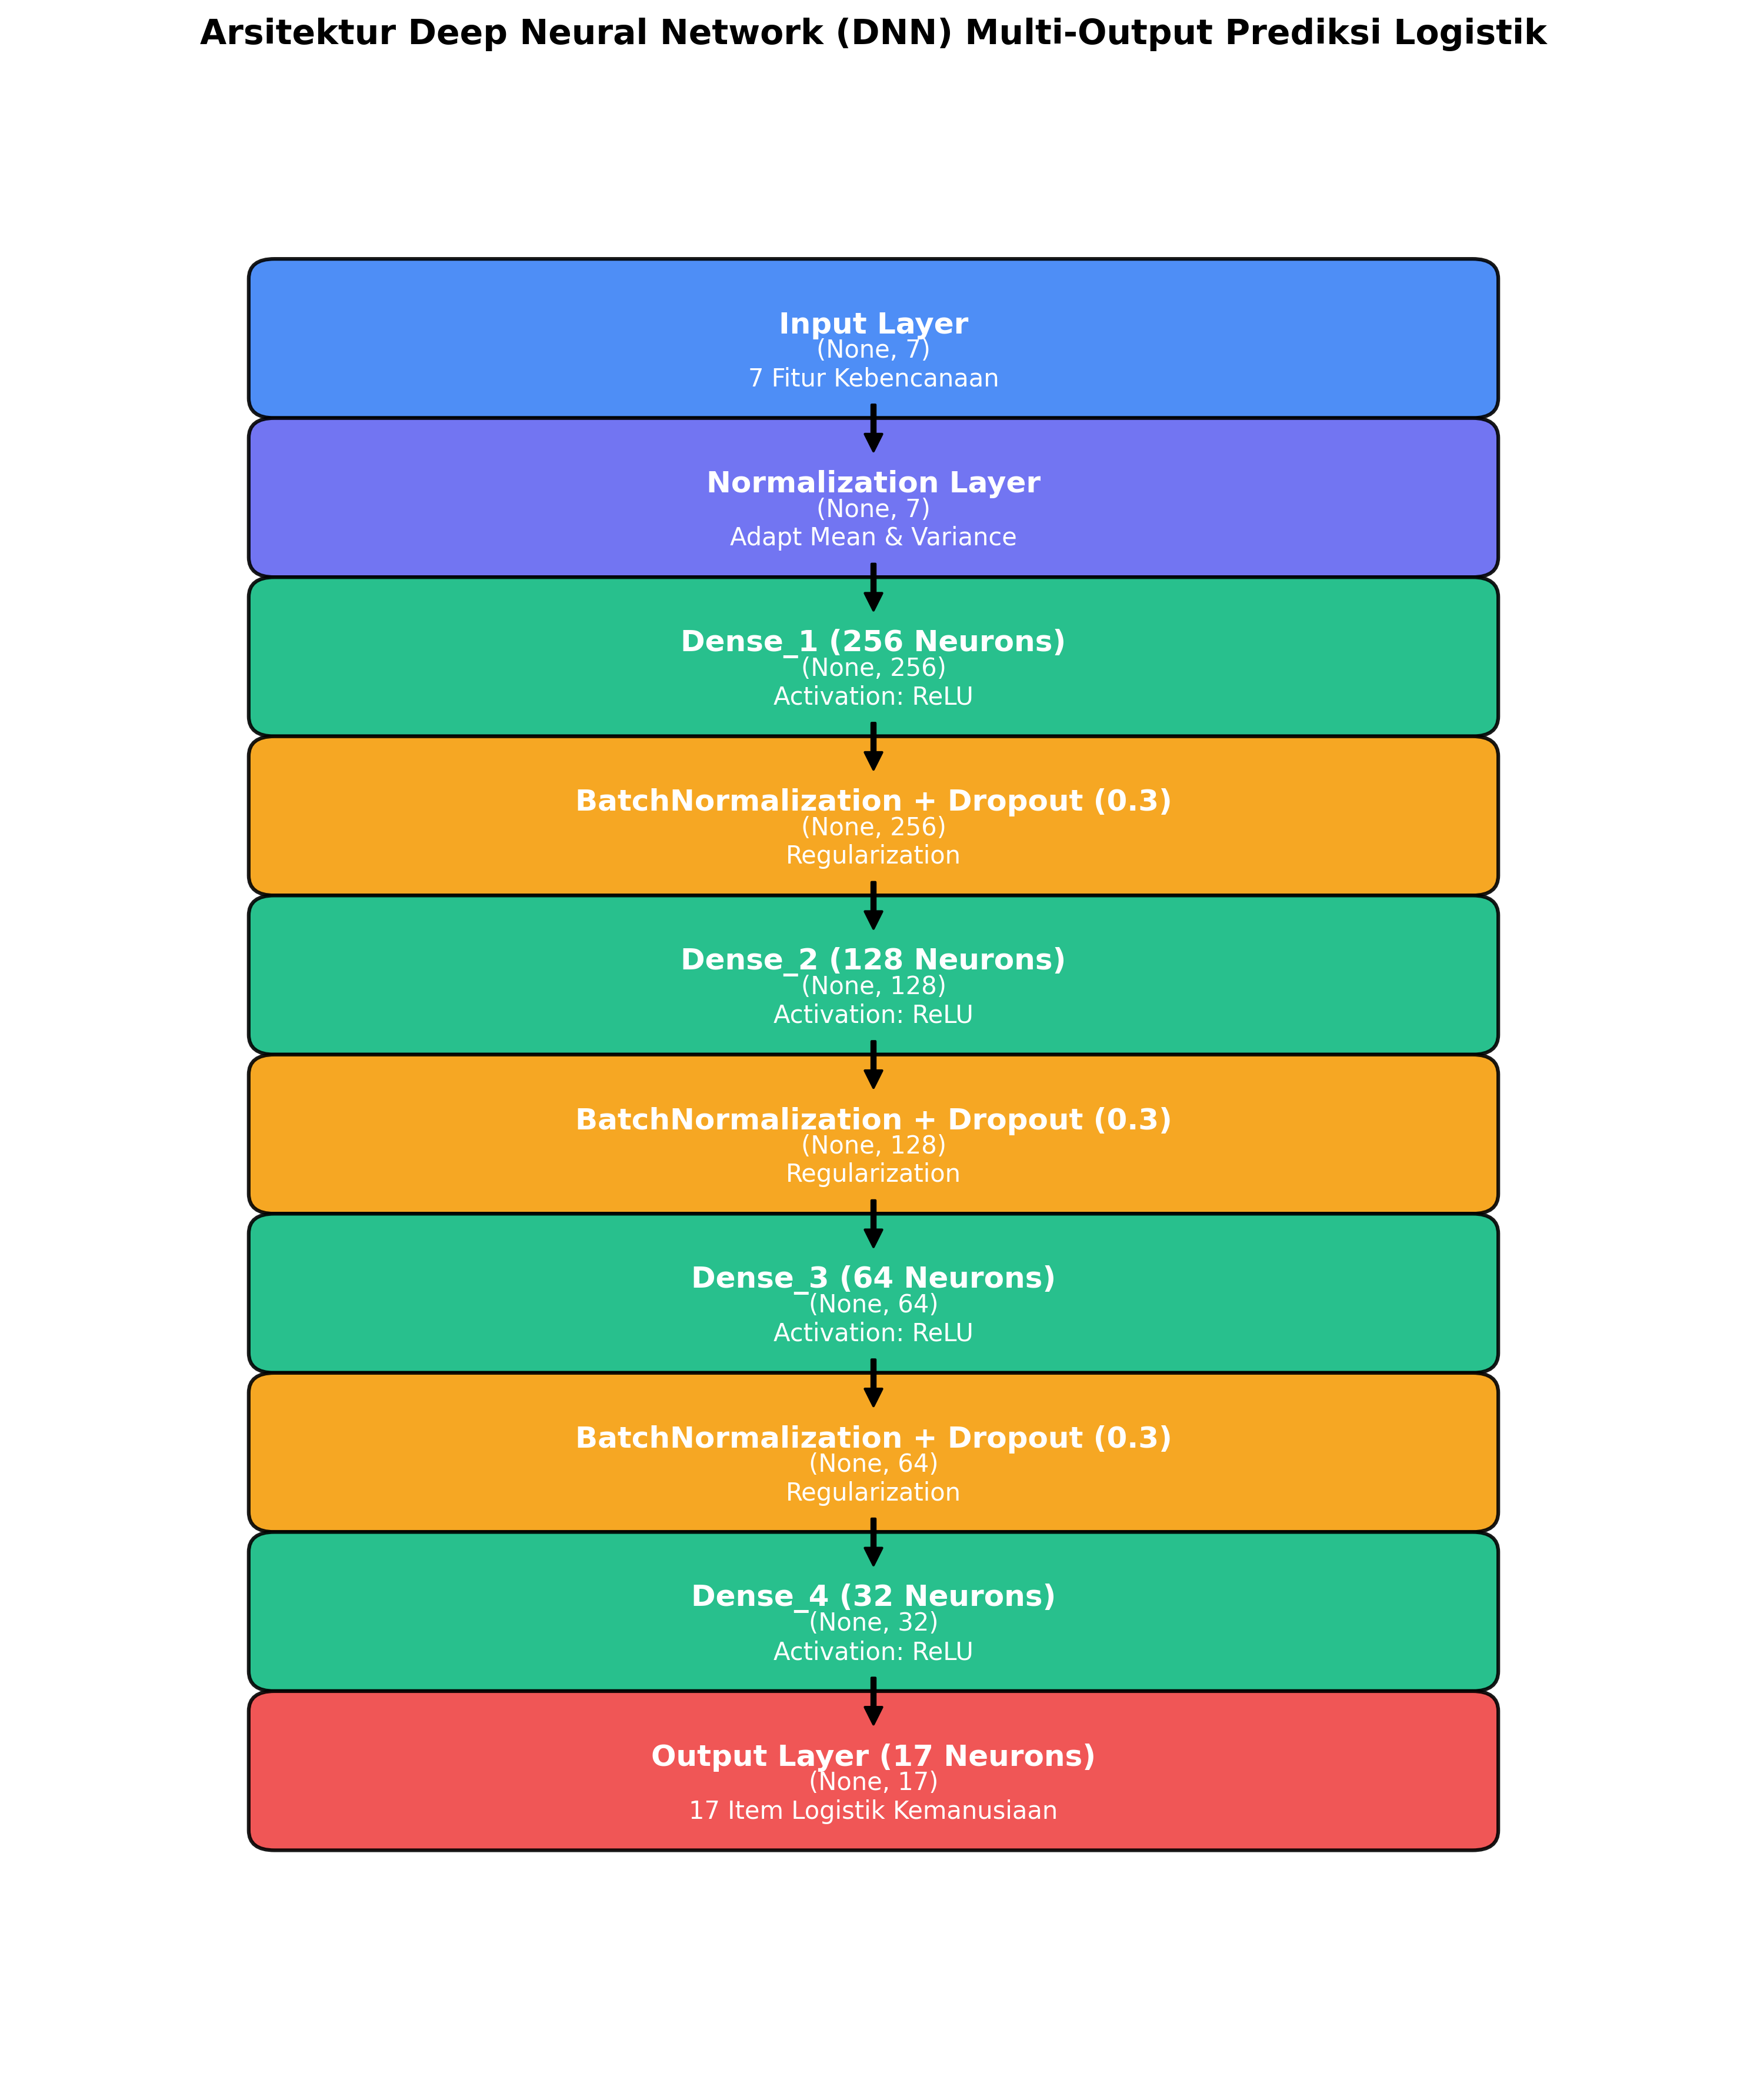

In [15]:
fig, ax = plt.subplots(figsize=(10, 12), dpi=300)
ax.set_xlim(0, 10)
ax.set_ylim(0, 15)
ax.axis('off')

layers_info = [
    ('Input Layer', '(None, 7)\n7 Fitur Kebencanaan', '#3b82f6'),
    ('Normalization Layer', '(None, 7)\nAdapt Mean & Variance', '#6366f1'),
    ('Dense_1 (256 Neurons)', '(None, 256)\nActivation: ReLU', '#10b981'),
    ('BatchNormalization + Dropout (0.3)', '(None, 256)\nRegularization', '#f59e0b'),
    ('Dense_2 (128 Neurons)', '(None, 128)\nActivation: ReLU', '#10b981'),
    ('BatchNormalization + Dropout (0.3)', '(None, 128)\nRegularization', '#f59e0b'),
    ('Dense_3 (64 Neurons)', '(None, 64)\nActivation: ReLU', '#10b981'),
    ('BatchNormalization + Dropout (0.3)', '(None, 64)\nRegularization', '#f59e0b'),
    ('Dense_4 (32 Neurons)', '(None, 32)\nActivation: ReLU', '#10b981'),
    ('Output Layer (17 Neurons)', '(None, 17)\n17 Item Logistik Kemanusiaan', '#ef4444')
]

y_pos = 13.5
for name, desc, color in layers_info:
    rect = patches.FancyBboxPatch((1.5, y_pos - 0.8), 7, 0.9, boxstyle='round,pad=0.15', facecolor=color, edgecolor='black', linewidth=1.5, alpha=0.9)
    ax.add_patch(rect)
    ax.text(5, y_pos - 0.25, name, ha='center', va='center', fontsize=12, fontweight='bold', color='white')
    ax.text(5, y_pos - 0.55, desc, ha='center', va='center', fontsize=10, color='white')
    if y_pos > 3.0:
        ax.annotate('', xy=(5, y_pos - 1.2), xytext=(5, y_pos - 0.85), arrowprops=dict(facecolor='black', edgecolor='black', width=1.5, headwidth=7, headlength=7))
    y_pos -= 1.2

plt.title('Arsitektur Deep Neural Network (DNN) Multi-Output Prediksi Logistik', fontsize=14, fontweight='bold', pad=20)
plt.tight_layout()
plt.savefig('arsitektur_model_logistics.png', bbox_inches='tight')
plt.show()


In [16]:
model.compile(optimizer=Adam(learning_rate=0.002), loss='mse', metrics=['mae'])

In [17]:
model.summary()

Model: "sequential"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 normalization (Normalizatio  (None, 7)                0         
 n)                                                              
                                                                 
 dense (Dense)               (None, 256)               2048      
                                                                 
 batch_normalization (BatchN  (None, 256)              1024      
 ormalization)                                                   
                                                                 
 dropout (Dropout)           (None, 256)               0         
                                                                 
 dense_1 (Dense)             (None, 128)               32896     
                                                                 
 batch_normalization_1 (Batc  (None, 128)              5

In [18]:
history = model.fit(
    X_train.values, y_train.values,
    validation_split=0.2,
    epochs=100,
    batch_size=128,
    verbose=1
)

Epoch 1/100
250/250 [==============================] - 217s 5ms/step - loss: 21127.7246 - mae: 70.3482 - val_loss: 2020.5712 - val_mae: 26.1760
Epoch 2/100
250/250 [==============================] - 1s 4ms/step - loss: 1480.7518 - mae: 22.9665 - val_loss: 537.1387 - val_mae: 15.5746
Epoch 3/100
250/250 [==============================] - 1s 4ms/step - loss: 1246.1255 - mae: 20.7943 - val_loss: 294.4912 - val_mae: 10.3895
Epoch 4/100
250/250 [==============================] - 1s 3ms/step - loss: 1158.8689 - mae: 19.9980 - val_loss: 277.1567 - val_mae: 9.9811
Epoch 5/100
250/250 [==============================] - 1s 3ms/step - loss: 1046.4941 - mae: 19.0473 - val_loss: 315.8079 - val_mae: 10.9838
Epoch 6/100
250/250 [==============================] - 1s 3ms/step - loss: 1080.9537 - mae: 19.2912 - val_loss: 249.6795 - val_mae: 9.5375
Epoch 7/100
250/250 [==============================] - 1s 4ms/step - loss: 995.8165 - mae: 18.4717 - val_loss: 248.1099 - val_mae: 9.4229
Epoch 8/100
250/250 

In [19]:
Y_pred_dl = model.predict(X_test.values)
r2_dl = r2_score(y_test, Y_pred_dl)
mae_dl = mean_absolute_error(y_test, Y_pred_dl)
rmse_dl = np.sqrt(mean_squared_error(y_test, Y_pred_dl))

313/313 [==============================] - 1s 2ms/step


In [20]:
print(f"R2 Score: {r2_dl:.4f} ({r2_dl*100:.2f}%)")
print(f"MAE: {mae_dl:.4f}")
print(f"RMSE: {rmse_dl:.4f}")

R2 Score: 0.9794 (97.94%)
MAE: 4.5551
RMSE: 9.3656


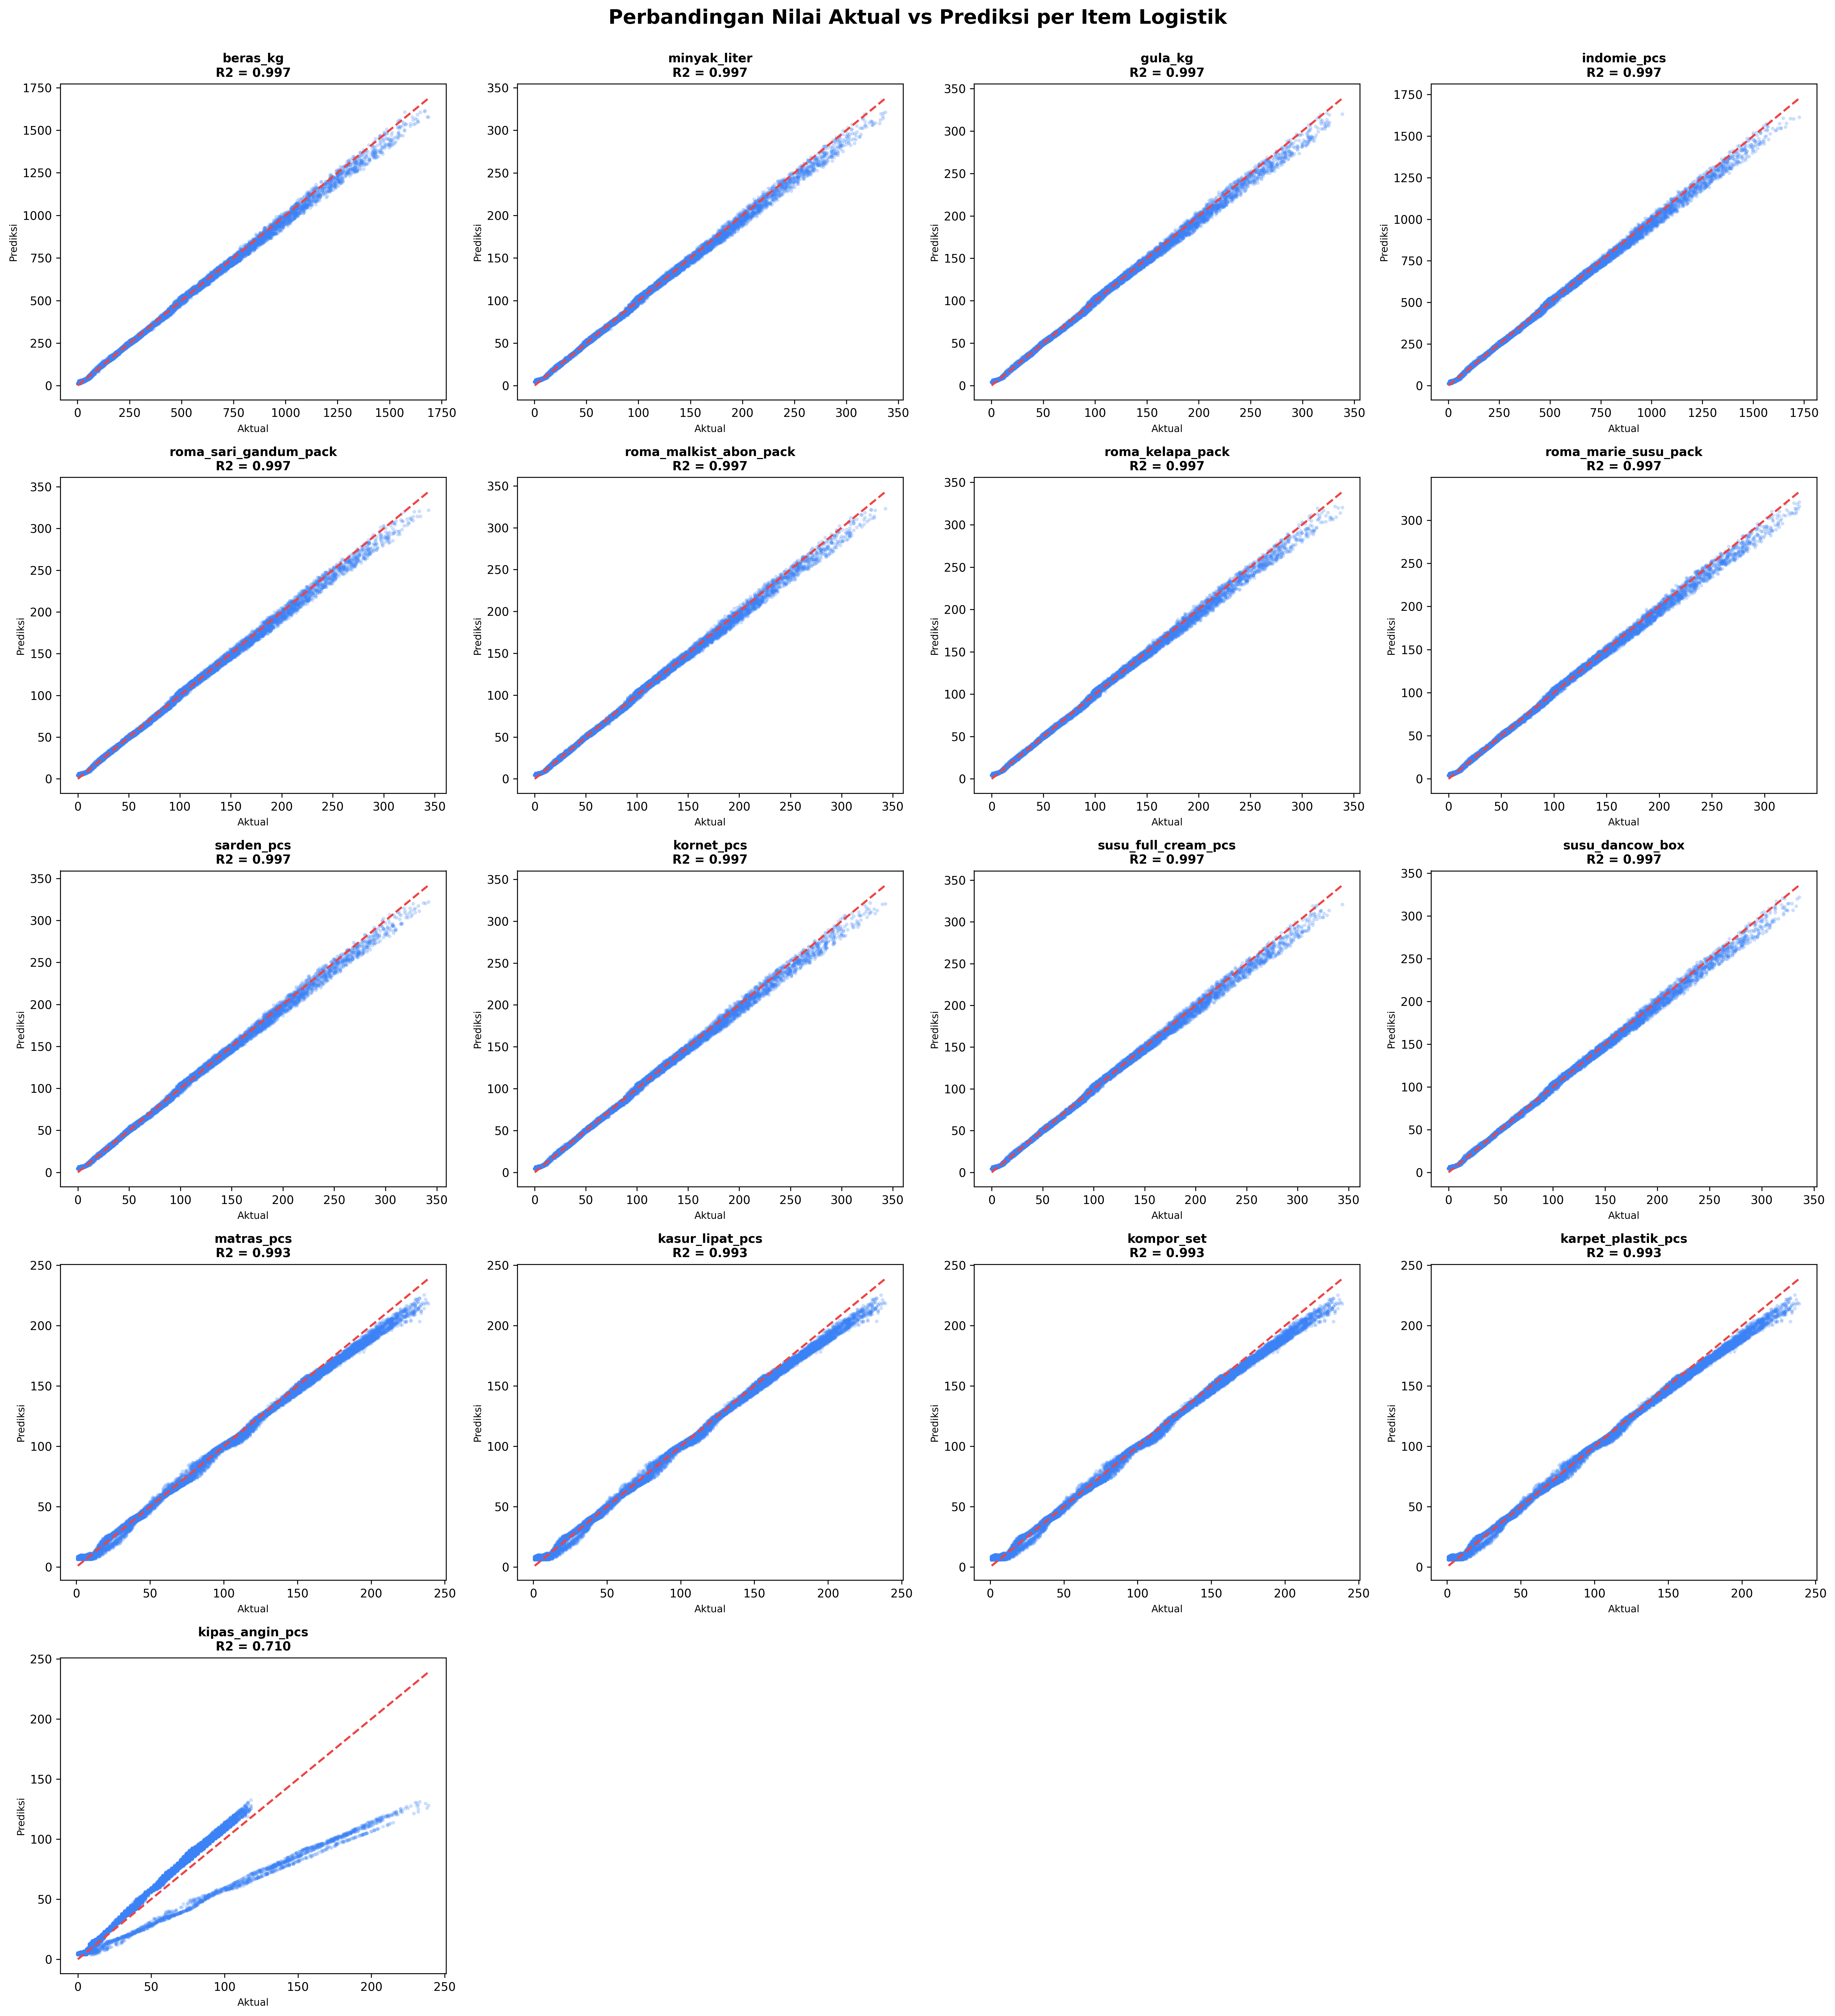

In [21]:
fig, axes = plt.subplots(5, 4, figsize=(22, 24), dpi=300)
axes = axes.flatten()
for i, col in enumerate(y.columns):
    actual = y_test[col].values
    predicted = Y_pred_dl[:, i]
    axes[i].scatter(actual, predicted, alpha=0.25, s=10, color="#3B82F6", edgecolors="none")
    min_val = min(actual.min(), predicted.min())
    max_val = max(actual.max(), predicted.max())
    axes[i].plot([min_val, max_val], [min_val, max_val], color="#EF4444", linewidth=1.8, linestyle="--")
    r2_item = r2_score(actual, predicted)
    axes[i].set_title(f"{col}\nR2 = {r2_item:.3f}", fontsize=10.5, fontweight="bold")
    axes[i].set_xlabel("Aktual", fontsize=8.5)
    axes[i].set_ylabel("Prediksi", fontsize=8.5)
for j in range(len(y.columns), len(axes)):
    axes[j].axis("off")
plt.suptitle("Perbandingan Nilai Aktual vs Prediksi per Item Logistik", fontsize=17, fontweight="bold", y=1.00)
plt.tight_layout()
plt.savefig("Prediction_vs_Actual_Comparison.png", dpi=300, bbox_inches="tight")
plt.show()

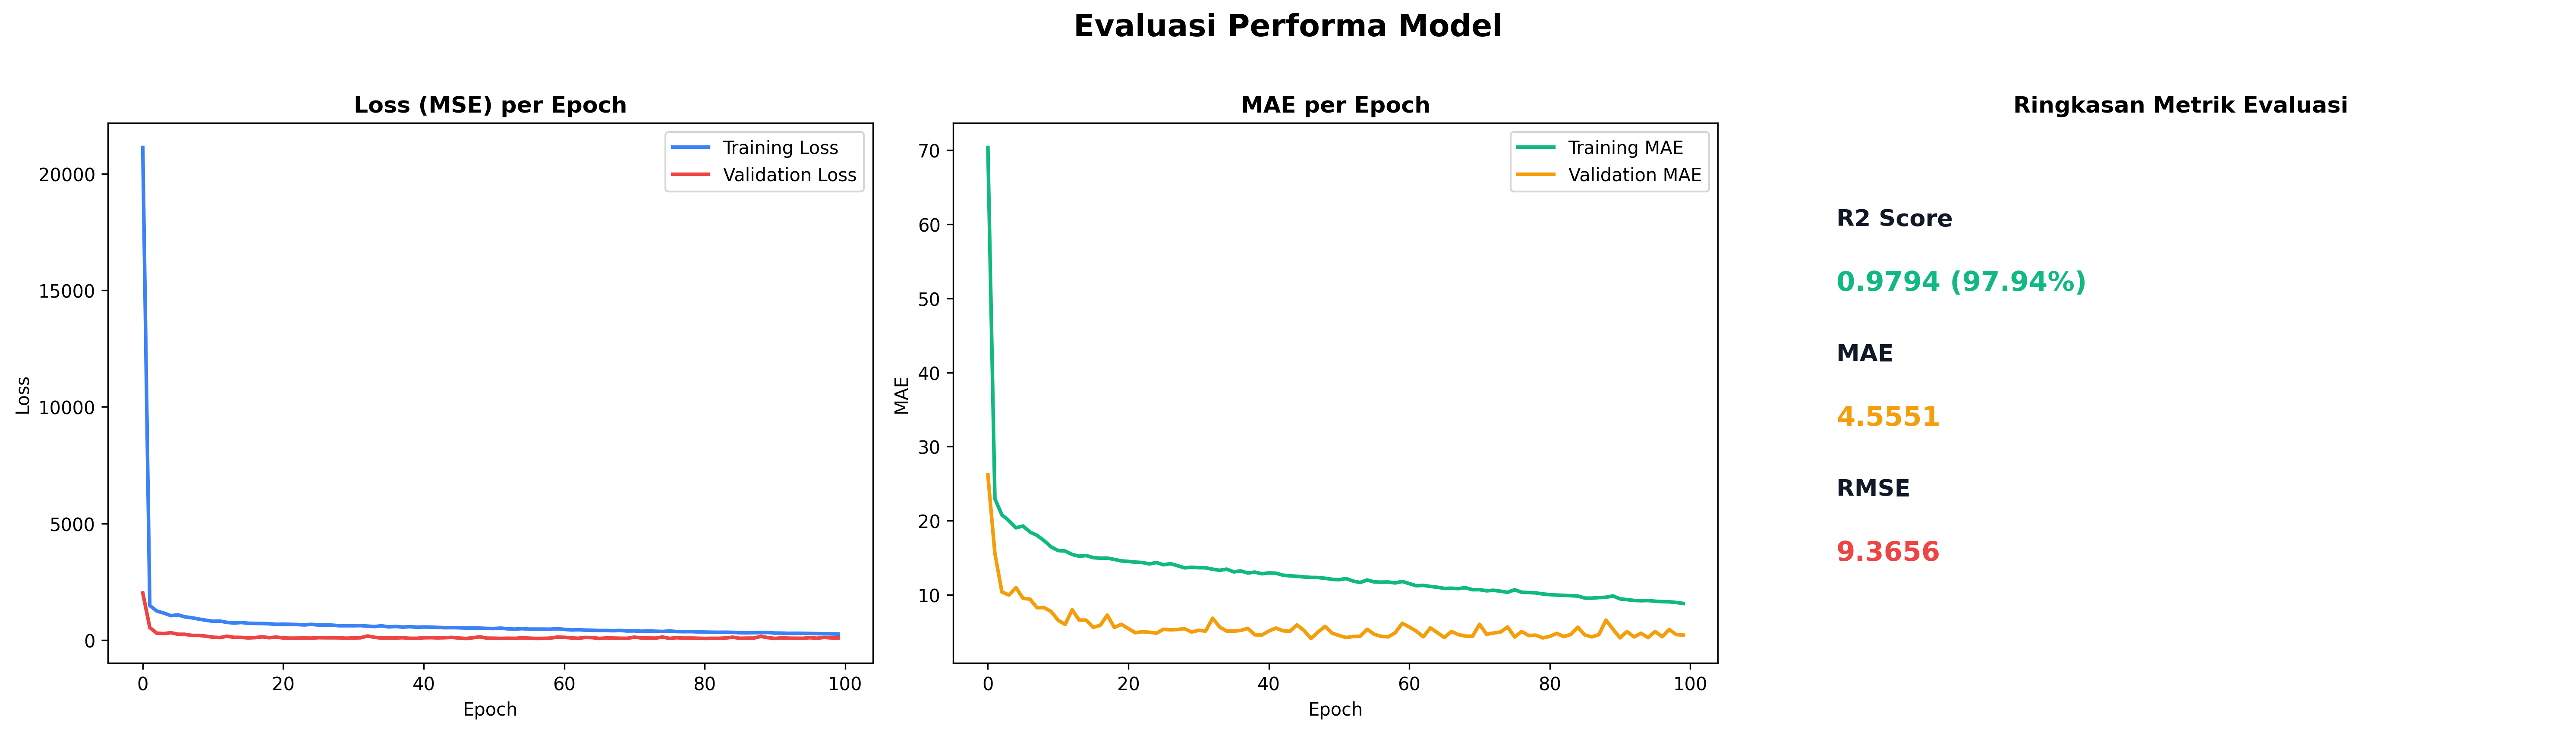

In [22]:
fig, axes = plt.subplots(1, 3, figsize=(20, 5.5), dpi=300)
axes[0].plot(history.history["loss"], color="#3B82F6", linewidth=2, label="Training Loss")
axes[0].plot(history.history["val_loss"], color="#EF4444", linewidth=2, label="Validation Loss")
axes[0].set_title("Loss (MSE) per Epoch", fontsize=12.5, fontweight="bold")
axes[0].set_xlabel("Epoch")
axes[0].set_ylabel("Loss")
axes[0].legend()
axes[1].plot(history.history["mae"], color="#10B981", linewidth=2, label="Training MAE")
axes[1].plot(history.history["val_mae"], color="#F59E0B", linewidth=2, label="Validation MAE")
axes[1].set_title("MAE per Epoch", fontsize=12.5, fontweight="bold")
axes[1].set_xlabel("Epoch")
axes[1].set_ylabel("MAE")
axes[1].legend()
axes[2].axis("off")
metric_labels = ["R2 Score", "MAE", "RMSE"]
metric_values = [r2_dl, mae_dl, rmse_dl]
metric_colors = ["#10B981", "#F59E0B", "#EF4444"]
y_pos = [0.75, 0.5, 0.25]
axes[2].set_xlim(0, 1)
axes[2].set_ylim(0, 1)
for label, val, color, yp in zip(metric_labels, metric_values, metric_colors, y_pos):
    axes[2].text(0.05, yp + 0.06, label, fontsize=13, fontweight="bold", color="#111827")
    display_val = f"{val:.4f} ({val*100:.2f}%)" if label == "R2 Score" else f"{val:.4f}"
    axes[2].text(0.05, yp - 0.06, display_val, fontsize=15, fontweight="bold", color=color)
axes[2].set_title("Ringkasan Metrik Evaluasi", fontsize=12.5, fontweight="bold")
plt.suptitle("Evaluasi Performa Model", fontsize=17, fontweight="bold", y=1.02)
plt.tight_layout()
plt.savefig("Evaluation_Metrics_Summary.png", dpi=300, bbox_inches="tight")
plt.show()

In [23]:
model.save("model_logistics.h5")